# Simulación Montecarlo del Sistema de Embarcaciones Turísticas en el Lago Titicaca

**Asignatura:** SIS230 — Modelado Sistémico y Simulación  
**Docente:** Dr. Ing. FLORES VELASQUEZ EDELFRE  
**Equipo:** Rendo Alfonte Tarqui · Yimmy Yeyson Cuyo Zamata · Cristian Alexis Loza Torres  
**Semestre:** 2026-I — Universidad Nacional del Altiplano, Puno

---

Este notebook presenta y analiza los artefactos oficiales generados por `scripts/generate_outputs.py`: CSV de resultados, validación de distribuciones y figuras comparativas. Las celdas con funciones de simulación quedan como apoyo metodológico e ilustrativo, no como fuente primaria de los resultados reportados.

> **Nota metodológica:** La ficha de observación sintética corresponde a una medición
> presencial oficial el 28 de mayo de 2026 de 9-10am. Fue construida académicamente a partir del PDF base, fuentes públicas
> (MINCETUR, SERNANP) y supuestos operativos coherentes con el sistema real.

## 1. Importación de librerías y parámetros globales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(2026)

# Parámetros del modelo base
DURACION_JORNADA      = 240   # minutos (06:00 a 10:00)
N_REPLICAS            = 1000
LAMBDA_GRUPOS_HORA    = 8
MEDIA_INTERLLEGADA    = 7.5   # 60 / 8
N_EMBARCACIONES       = 3
CAPACIDAD             = 30
UMBRAL_SALIDA         = 24
ESPERA_MAXIMA_SALIDA  = 15
TIEMPO_PREPARACION   = 10

print('Parámetros cargados correctamente.')

Parámetros cargados correctamente.


## 2. Ficha de observación sintética

Se construyó una ficha representativa de la ventana 09:00–10:00 del 28 de mayo de 2026,
basada en fuentes públicas y supuestos coherentes con la tasa de 8 grupos/hora.

In [2]:
df_ficha = pd.read_csv('../data/ficha_observacion_sintetica.csv')
print('Ficha de observación sintética:')
display(df_ficha)

resumen_ficha = pd.DataFrame({
    'Indicador': [
        'Grupos observados', 'Turistas observados',
        'Interllegada promedio (min)', 'Registro promedio (min)',
        'Tamaño promedio de grupo'
    ],
    'Valor': [
        len(df_ficha),
        df_ficha['Tamano_grupo'].sum(),
        round(df_ficha['Interllegada_min'].mean(), 2),
        round(df_ficha['Registro_min'].mean(), 2),
        round(df_ficha['Tamano_grupo'].mean(), 2)
    ]
})
print('\nResumen de la ventana observada:')
display(resumen_ficha)

Ficha de observación sintética:


,N_grupo,Hora_llegada,Interllegada_min,Tamano_grupo,Registro_min,Destino,Observacion
0,1,09:03,3,6,4.1,Uros,Grupo familiar pequeño
1,2,09:10,7,12,5.3,Uros,Grupo con guía local
2,3,09:18,8,8,3.8,Uros,Registro rápido
3,4,09:25,7,15,6.2,Uros,Pago dividido
4,5,09:34,9,4,3.4,Uros,Grupo pequeño
5,6,09:40,6,18,6.8,Uros,Grupo grande
6,7,09:48,8,10,4.7,Uros,Grupo mixto
7,8,09:56,8,7,5.0,Uros,Grupo familiar



Resumen de la ventana observada:


,Indicador,Valor
0,Grupos observados,8.00
1,Turistas observados,80.00
2,Interllegada promedio (min),7.00
3,Registro promedio (min),4.91
4,Tamaño promedio de grupo,10.00


## 3. Generadores de variables aleatorias

In [3]:
def uniform_inverse(rng, low, high, size=None):
    """Uniforme(a,b) por transformada inversa: X = a + (b-a)U."""
    u = rng.random(size)
    return low + (high - low) * u

def exponential_inverse(rng, mean, size=None):
    """Exponencial(media) por transformada inversa: X = -media ln(1-U)."""
    u = rng.random(size)
    return -mean * np.log1p(-u)

def triangular_inverse(rng, left, mode, right, size=None):
    """Triangular(a,c,b) por transformada inversa de la CDF por tramos."""
    u = rng.random(size)
    split = (mode - left) / (right - left)
    lower = left + np.sqrt(u * (right - left) * (mode - left))
    upper = right - np.sqrt((1.0 - u) * (right - left) * (right - mode))
    value = np.where(u < split, lower, upper)
    return float(value) if size is None else value

def normal_box_muller(rng, mean=5, sd=1, size=None):
    """Normal por Box-Muller; transformada exacta desde dos uniformes independientes."""
    u1 = rng.random(size)
    u2 = rng.random(size)
    return mean + sd * np.sqrt(-2.0 * np.log(u1)) * np.cos(2.0 * np.pi * u2)

def generar_interllegada(rng, media=7.5):
    return exponential_inverse(rng, media)

def generar_tamano_grupo(rng):
    return max(1, int(round(triangular_inverse(rng, 4, 10, 18))))

def generar_registro(rng):
    return triangular_inverse(rng, 3, 5, 7)

def generar_navegacion(rng):
    return uniform_inverse(rng, 25, 40)

def generar_permanencia(rng):
    return triangular_inverse(rng, 45, 90, 180)

print('Generadores por transformada definidos.')

Generadores por transformada definidos.


## 4. Validación de distribuciones

Se generaron 10 000 muestras por variable para comparar media y varianza muestral contra sus valores teóricos. La Normal truncada se incluye como validación complementaria del registro; el escenario final mantiene registro triangular.

In [4]:
df_validacion = pd.read_csv('../results/validacion_distribuciones.csv')
print('Validación de distribuciones (n = 10 000, semilla 2026):')
display(df_validacion)

Validación de distribuciones (n = 10 000, semilla 2026):


,Variable,Distribucion,Media_Muestral,Media_Teorica,Diferencia_Media,Varianza_Muestral,Varianza_Teorica,Diferencia_Varianza
0,Interllegadas,Exponencial,7.6518,7.5000,0.1518,58.5814,56.2500,2.3314
1,Tamano Grupo,Triangular discreta redondeada,10.6404,10.6667,-0.0263,8.1895,8.3056,-0.1161
2,Registro Triangular,Triangular,4.9867,5.0000,-0.0133,0.6748,0.6667,0.0081
3,Registro Normal Truncada,Normal truncada,5.0089,5.0000,0.0089,0.7682,0.7737,-0.0055
4,Navegacion Ida,Uniforme,32.5167,32.5000,0.0167,18.7785,18.7500,0.0285
5,Permanencia,Triangular,104.7282,105.0000,-0.2718,792.2103,787.5000,4.7103


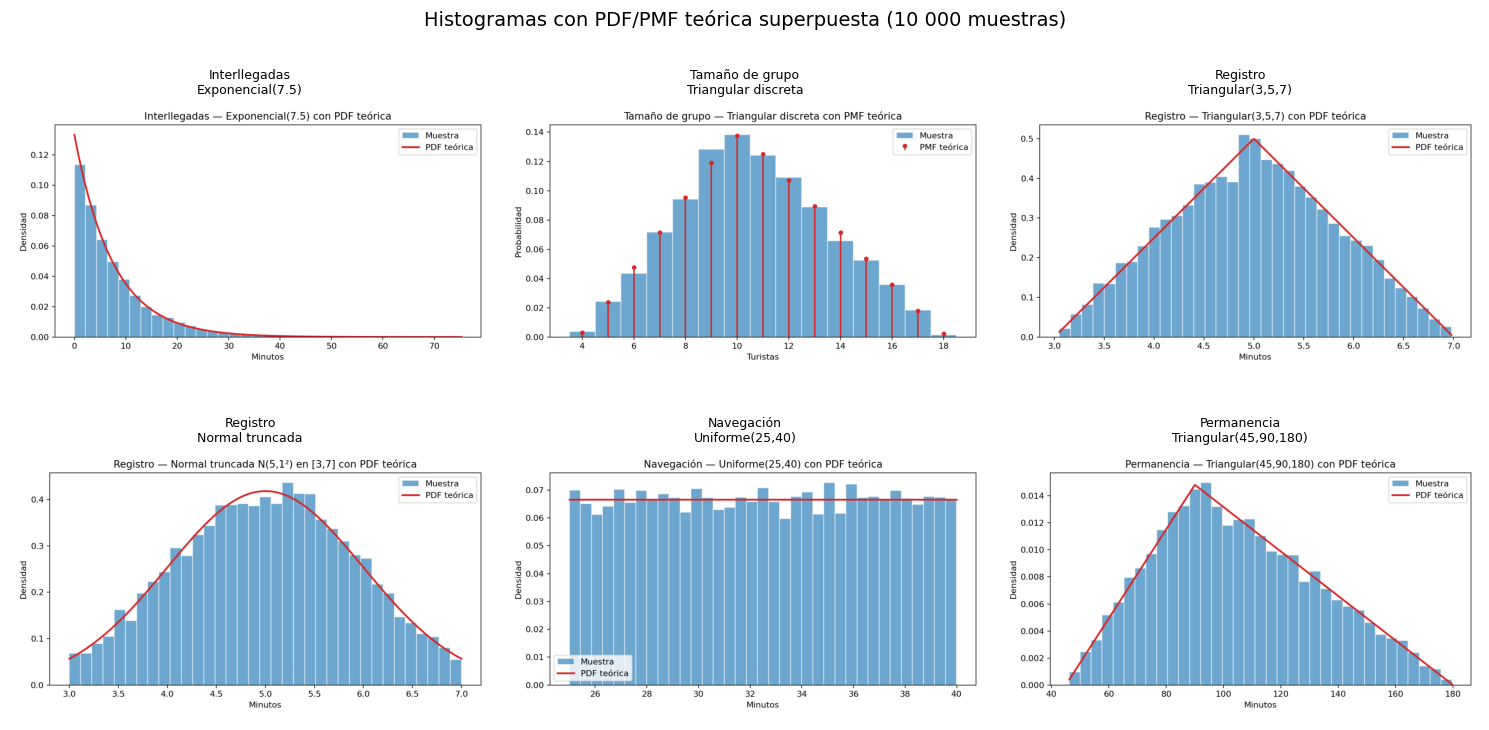

In [5]:
import os

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Histogramas con PDF/PMF teórica superpuesta (10 000 muestras)', fontsize=14)

hist_files = [
    ('../figures/hist_interllegadas.png', 'Interllegadas\nExponencial(7.5)'),
    ('../figures/hist_tamano_grupo.png',  'Tamaño de grupo\nTriangular discreta'),
    ('../figures/hist_registro.png',      'Registro\nTriangular(3,5,7)'),
    ('../figures/hist_registro_normal.png', 'Registro\nNormal truncada'),
    ('../figures/hist_navegacion.png',    'Navegación\nUniforme(25,40)'),
    ('../figures/hist_permanencia.png',   'Permanencia\nTriangular(45,90,180)'),
]

for ax, (path, title) in zip(axes.flat, hist_files):
    img = plt.imread(path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Generación de grupos con ventanilla FIFO

In [6]:
def generar_grupos(rng, duracion, lambda_grupos):
    """Genera llegadas de grupos turísticos hasta t=duracion.
    Calcula fin de registro con ventanilla única FIFO.
    """
    t = 0.0
    grupos = []
    while True:
        t += exponential_inverse(rng, mean=60.0 / lambda_grupos)
        if t > duracion:
            break
        grupos.append({
            't_llegada': t,
            'tamano':    max(1, int(round(triangular_inverse(rng, 4, 10, 18)))),
            't_registro': triangular_inverse(rng, 3, 5, 7),
        })
    fin_ventanilla = 0.0
    for g in grupos:
        inicio = max(g['t_llegada'], fin_ventanilla)
        g['fin_reg']     = inicio + g['t_registro']
        fin_ventanilla   = g['fin_reg']
    return grupos

# Ejemplo de una réplica
rng_demo = np.random.default_rng(2026)
grupos_demo = generar_grupos(rng_demo, 30, 8)  # primeros 30 minutos
df_demo = pd.DataFrame(grupos_demo)[['t_llegada', 'tamano', 't_registro', 'fin_reg']].round(2)
df_demo.columns = ['Llegada (min)', 'Tamaño', 'Registro (min)', 'Fin registro']
print(f'Grupos generados en primeros 30 min de demo: {len(df_demo)}')
display(df_demo)

Grupos generados en primeros 30 min de demo: 4


,Llegada (min),Tamaño,Registro (min),Fin registro
0,1.48,12,4.93,6.41
1,4.95,9,5.71,12.12
2,22.62,8,5.33,27.95
3,25.27,16,6.20,34.15


## 6. Simulación de una jornada

### Reglas operativas
- Una embarcación sale si llega a **24 turistas (umbral)** o si el primer grupo
  lleva **15 minutos esperando**.
- Los grupos no se dividen.
- Una embarcación no puede partir después del cierre de jornada (t > 240 min).
- Turistas no atendidos = grupos en cola al cierre.
- Espera = tiempo desde llegada del grupo hasta que la embarcación parte.

In [7]:
def simular_jornada(
    rng, duracion=240, lambda_grupos=8,
    n_embarcaciones=3, capacidad=30,
    t_prep=10, umbral=24, espera_max=15
):
    cola   = generar_grupos(rng, duracion, lambda_grupos)
    cola.sort(key=lambda g: g['fin_reg'])
    botes  = [0.0] * n_embarcaciones
    esperas, sistemas, esperas_cola = [], [], []
    viajes = 0; atendidos = 0; ocupado = 0.0

    while cola:
        bote_idx = int(np.argmin(botes))
        t_inicio = max(botes[bote_idx], cola[0]['fin_reg'])

        if t_inicio > duracion:  # jornada cerrada
            break

        t = t_inicio
        carga, cargados, i = 0, [], 0
        limite = cola[0]['fin_reg'] + espera_max

        while i < len(cola):
            g = cola[i]
            if g['fin_reg'] > max(t, limite):
                break
            t = max(t, g['fin_reg'])
            if carga + g['tamano'] <= capacidad:
                carga += g['tamano']
                cargados.append(g)
                i += 1
                if carga >= umbral:
                    break
            else:
                break

        if not cargados:
            botes[bote_idx] = cola[0]['fin_reg']
            continue

        salida = t if carga >= umbral else max(t, limite)

        if salida > duracion:  # no parte tras el cierre
            break

        ciclo_sin_prep = (
            uniform_inverse(rng, 25, 40) +
            triangular_inverse(rng, 45, 90, 180) +
            uniform_inverse(rng, 25, 40)
        )
        ciclo_total = ciclo_sin_prep + t_prep

        # Tiempo activo dentro de la ventana de la jornada
        ocupado += min(salida + ciclo_total, duracion) - salida
        botes[bote_idx] = salida + ciclo_total
        viajes    += 1
        atendidos += carga

        for g in cargados:
            espera = salida - g['t_llegada']          # desde llegada
            esperas.append(espera)
            esperas_cola.append(max(0., salida - g['fin_reg']))
            sistemas.append(espera + ciclo_sin_prep)

        cola = cola[len(cargados):]

    no_atendidos = sum(g['tamano'] for g in cola)
    tiempo_total  = duracion * n_embarcaciones
    espera_prom   = float(np.mean(esperas)) if esperas else 0.0
    return {
        'Espera_Promedio':       espera_prom,
        'Sistema_Promedio':      float(np.mean(sistemas))       if sistemas      else 0.0,
        'Longitud_Cola':         (lambda_grupos / 60.0) * espera_prom,
        'Utilizacion':           ocupado / tiempo_total          if tiempo_total  else 0.0,
        'Porcentaje_Espera':     float(np.mean(np.array(esperas_cola) > 0)) if esperas_cola else 0.0,
        'Percentil_95_Espera':   float(np.percentile(esperas, 95))          if esperas      else 0.0,
        'Turistas_Atendidos':    atendidos,
        'Turistas_No_Atendidos': no_atendidos,
        'Viajes':                viajes,
        'Ocupacion_Promedio':    atendidos / (viajes * capacidad) if viajes else 0.0,
    }

print('Función simular_jornada definida.')

Función simular_jornada definida.


In [8]:
# Ejemplo de una sola jornada
rng_demo = np.random.default_rng(2026)
resultado_demo = simular_jornada(rng_demo)
print('Resultado de una sola jornada (demo):')
for k, v in resultado_demo.items():
    print(f'  {k:30s}: {round(v, 3)}')

Resultado de una sola jornada (demo):
  Espera_Promedio               : 89.914
  Sistema_Promedio              : 268.02
  Longitud_Cola                 : 11.989
  Utilizacion                   : 0.848
  Porcentaje_Espera             : 0.923
  Percentil_95_Espera           : 162.869
  Turistas_Atendidos            : 141
  Turistas_No_Atendidos         : 308
  Viajes                        : 6
  Ocupacion_Promedio            : 0.783


## 7. Escenario base oficial — resultados generados por script

In [9]:
df_resultados = pd.read_csv('../results/resultados_escenarios.csv')
df_base = df_resultados[df_resultados['Escenario'] == 'E0 Base'].drop(columns='Escenario')

print('Métricas oficiales del escenario base — generadas por scripts/generate_outputs.py:')
resumen_base = df_base.T.reset_index()
resumen_base.columns = ['Métrica', 'Promedio']
display(resumen_base.round(3))

Métricas oficiales del escenario base — generadas por scripts/generate_outputs.py:


,Métrica,Promedio
0,Espera_Promedio,66.170
1,Sistema_Promedio,238.306
2,Longitud_Cola,8.823
3,Utilizacion,0.830
4,Porcentaje_Espera,0.871
5,Percentil_95_Espera,142.584
6,Turistas_Atendidos,119.277
7,Turistas_No_Atendidos,224.861
8,Viajes,5.115
9,Ocupacion_Promedio,0.775


## 8. Escenarios alternativos E0–E4

In [10]:
print('Tabla comparativa oficial de escenarios (promedio de 1 000 réplicas):')
display(df_resultados.round(3))

Tabla comparativa oficial de escenarios (promedio de 1 000 réplicas):


,Escenario,Espera_Promedio,Sistema_Promedio,Longitud_Cola,Utilizacion,Porcentaje_Espera,Percentil_95_Espera,Turistas_Atendidos,Turistas_No_Atendidos,Viajes,Ocupacion_Promedio
0,E0 Base,66.170,238.306,8.823,0.830,0.871,142.584,119.277,224.861,5.115,0.775
1,E1 Más embarcaciones,55.020,225.761,7.336,0.792,0.868,126.488,149.332,194.299,6.443,0.770
2,E2 Menor preparación,66.104,237.360,8.814,0.826,0.879,139.926,122.042,219.895,5.244,0.773
3,E3 Mayor capacidad,62.063,233.154,8.275,0.807,0.928,129.384,149.430,191.285,5.015,0.739
4,E4 Alta demanda,71.086,242.647,11.848,0.843,0.862,153.225,126.017,299.867,5.271,0.796


## 9. Comparación de métricas clave

In [11]:
metricas_clave = df_resultados[[
    'Escenario', 'Espera_Promedio', 'Percentil_95_Espera',
    'Utilizacion', 'Turistas_Atendidos', 'Turistas_No_Atendidos'
]].copy()
metricas_clave['Utilizacion'] = (metricas_clave['Utilizacion'] * 100).round(1)
metricas_clave = metricas_clave.rename(columns={
    'Espera_Promedio':       'Espera prom. (min)',
    'Percentil_95_Espera':   'P95 espera (min)',
    'Utilizacion':           'Utiliz. (%)',
    'Turistas_Atendidos':    'Atendidos',
    'Turistas_No_Atendidos': 'No atendidos',
})
display(metricas_clave)

,Escenario,Espera prom. (min),P95 espera (min),Utiliz. (%),Atendidos,No atendidos
0,E0 Base,66.170,142.584,83.0,119.277,224.861
1,E1 Más embarcaciones,55.020,126.488,79.2,149.332,194.299
2,E2 Menor preparación,66.104,139.926,82.6,122.042,219.895
3,E3 Mayor capacidad,62.063,129.384,80.7,149.430,191.285
4,E4 Alta demanda,71.086,153.225,84.3,126.017,299.867


## 10. Gráficos finales

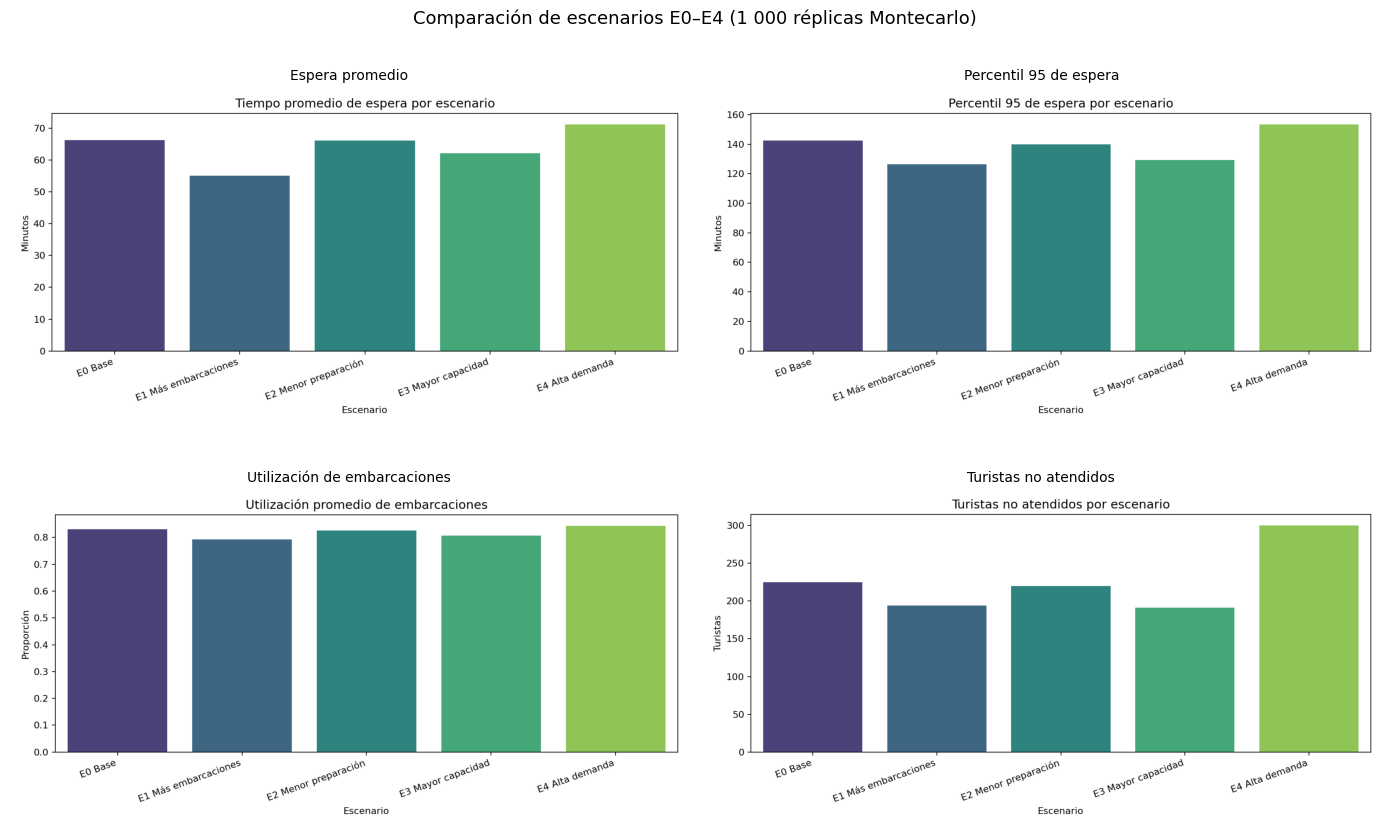

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Comparación de escenarios E0–E4 (1 000 réplicas Montecarlo)', fontsize=13)

plot_files = [
    ('../figures/escenarios_espera_promedio.png',    'Espera promedio'),
    ('../figures/escenarios_percentil95.png',         'Percentil 95 de espera'),
    ('../figures/escenarios_utilizacion.png',         'Utilización de embarcaciones'),
    ('../figures/escenarios_turistas_no_atendidos.png','Turistas no atendidos'),
]

for ax, (path, title) in zip(axes.flat, plot_files):
    img = plt.imread(path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

## 11. Distribución de esperas — escenario base vs. E1

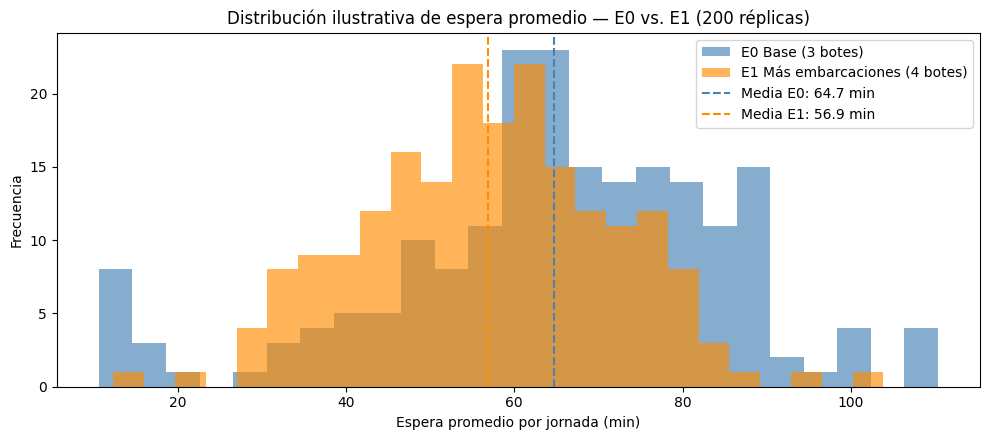

In [13]:
# Visualización complementaria: no reemplaza los CSV/figuras oficiales del script.
rng_cmp = np.random.default_rng(2026)
esperas_e0 = []
esperas_e1 = []

for _ in range(200):  # 200 réplicas para visualización rápida
    r0 = simular_jornada(rng_cmp, n_embarcaciones=3)
    esperas_e0.append(r0['Espera_Promedio'])
    r1 = simular_jornada(rng_cmp, n_embarcaciones=4)
    esperas_e1.append(r1['Espera_Promedio'])

plt.figure(figsize=(10, 4.5))
plt.hist(esperas_e0, bins=25, alpha=0.65, label='E0 Base (3 botes)',           color='steelblue')
plt.hist(esperas_e1, bins=25, alpha=0.65, label='E1 Más embarcaciones (4 botes)', color='darkorange')
plt.axvline(np.mean(esperas_e0), color='steelblue',   linestyle='--', linewidth=1.5,
            label=f'Media E0: {np.mean(esperas_e0):.1f} min')
plt.axvline(np.mean(esperas_e1), color='darkorange',  linestyle='--', linewidth=1.5,
            label=f'Media E1: {np.mean(esperas_e1):.1f} min')
plt.title('Distribución ilustrativa de espera promedio — E0 vs. E1 (200 réplicas)')
plt.xlabel('Espera promedio por jornada (min)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Conclusiones técnicas del notebook

### Hallazgos principales

1. **El sistema base es estructuralmente congestionado.** El ciclo promedio de una
   embarcación (navegación + permanencia + retorno + preparación ≈ 180 min) supera
   la capacidad de completar más de 2 viajes en la jornada de 4 horas. Esto limita
   la atención efectiva a ≈ 120 turistas sobre una demanda de ≈ 345.

2. **E2 (menor preparación) tiene impacto marginal.** El tiempo de preparación
   representa solo el 5,6% del ciclo total. Reducirlo a la mitad no permite un
   viaje adicional y la mejora en espera es < 0,1 min.

3. **E1 y E3 son las alternativas más efectivas.** Agregar una embarcación (E1)
   o aumentar la capacidad a 40 (E3) reduce turistas no atendidos en ≈ 33–35 por jornada.

4. **E4 confirma fragilidad ante alta demanda.** Con 10 grupos/hora el sistema acumula
   304 turistas no atendidos por jornada, un 35% más que en E0.

### Recomendación operativa

E1 resulta atractivo por mejorar el desempeño operativo, aunque su factibilidad económica debe evaluarse por separado.
- **Prioridad: E1** — incorporar una cuarta embarcación.
- **Alternativa: E3** — reemplazar las 3 embarcaciones por unidades de mayor capacidad.
- **No recomendado: E2** — el impacto no justifica la optimización del proceso de preparación.